In [1]:
### Imports
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import DiagonalGate

In [2]:
### Helper Functions

def gray_code(n: int):
    return [i ^ (i >> 1) for i in range(1 << n)]

def _fwht(vec: np.ndarray) -> np.ndarray:
    y = vec.astype(float).copy()
    h, N = 1, y.size
    while h < N:
        for i in range(0, N, h*2):
            for j in range(i, i+h):
                u, v = y[j], y[j+h]
                y[j], y[j+h] = u+v, u-v
        h <<= 1
    return y

def Walsh_coefficients(matrix: np.ndarray) -> np.ndarray:
    assert matrix.ndim == 2 and matrix.shape[0] == matrix.shape[1]
    N = matrix.shape[0]
    assert N & (N-1) == 0 and N > 0
    
    d = np.diag(matrix)
    assert np.allclose(matrix, np.diag(d))
    assert np.allclose(np.abs(d), 1.0, atol=1e-12)

    f = np.angle(d)   
    a = _fwht(f) / N
    return a

In [3]:
def build_optimal_walsh_circuit(matrix):
    aj = np.real(Walsh_coefficients(matrix)) # get aj's for the 2**n diagonal
    n = int(np.log2(len(aj)))
    qc = QuantumCircuit(n)
    
    # Apply the global phase corresponding to the 0-th Walsh coefficient
    qc.global_phase = aj[0]
    
    gray_seq = gray_code(n)
    
    # Array tracking the parity expression currently held by each qubit.
    current_parity = [1 << q for q in range(n)]
    
    for g_i in gray_seq[1:]:
        # The target qubit is the most significant bit of the current Gray code
        target = g_i.bit_length() - 1
        
        # Find the difference between current parity of target and the required parity g_i
        diff = current_parity[target] ^ g_i
        
        # If there's a difference, apply a CNOT to update the parity
        if diff != 0:
            # Due to Gray code properties, the difference is guaranteed to be a single bit (power of 2)
            ctrl = diff.bit_length() - 1
            qc.cx(ctrl, target)
            current_parity[target] = g_i
            
        theta = -2.0 * aj[g_i]
        
    
        # exactly 2^n - 1 RZ gates and 2^n - 2 CX gates, maintaining standard structure.
        qc.rz(theta, target)
            
    return qc

Testing

In [ ]:
# total depth should be 2**num_qubits -3

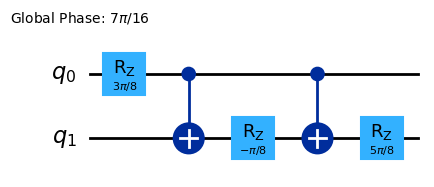

In [4]:
# two qubit test
phases_2q = np.array([0, np.pi/4, np.pi/2, np.pi])
diagU_2q = np.diag(np.exp(1j * phases_2q))
qc=build_optimal_walsh_circuit(diagU_2q)
qc.draw('mpl')

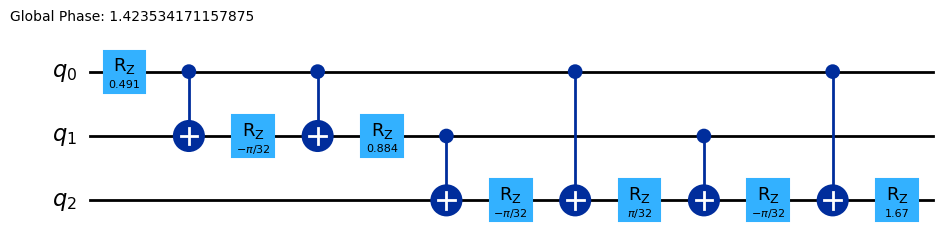

In [5]:
# 3 qubit test
phases_3q = np.array([
    0,           
    np.pi/8,     
    np.pi/4,     
    3*np.pi/8,   
    np.pi/2,     
    5*np.pi/8,   
    3*np.pi/4,   
    np.pi        
], dtype=float)

diagU_3q = np.diag(np.exp(1j * phases_3q))
qc_3q = build_optimal_walsh_circuit(diagU_3q)
qc_3q.draw('mpl')

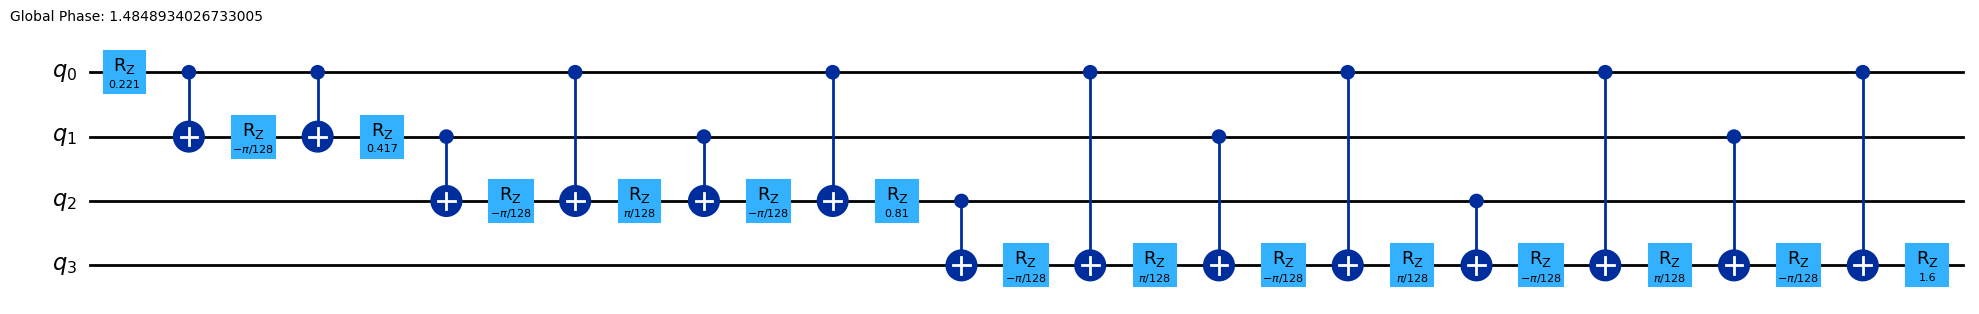

In [6]:
# 4 qubit test
phases_4q = np.array([
    0,
    np.pi/16,
    np.pi/8,
    3*np.pi/16,
    np.pi/4,
    5*np.pi/16,
    3*np.pi/8,
    7*np.pi/16,
    np.pi/2,
    9*np.pi/16,
    5*np.pi/8,
    11*np.pi/16,
    3*np.pi/4,
    13*np.pi/16,
    7*np.pi/8,
    np.pi
], dtype=float)

diagU_4q = np.diag(np.exp(1j * phases_4q))
qc_4q = build_optimal_walsh_circuit(diagU_4q)
qc_4q.draw('mpl', fold=-1)

Generated 5-qubit circuit with depth: 61


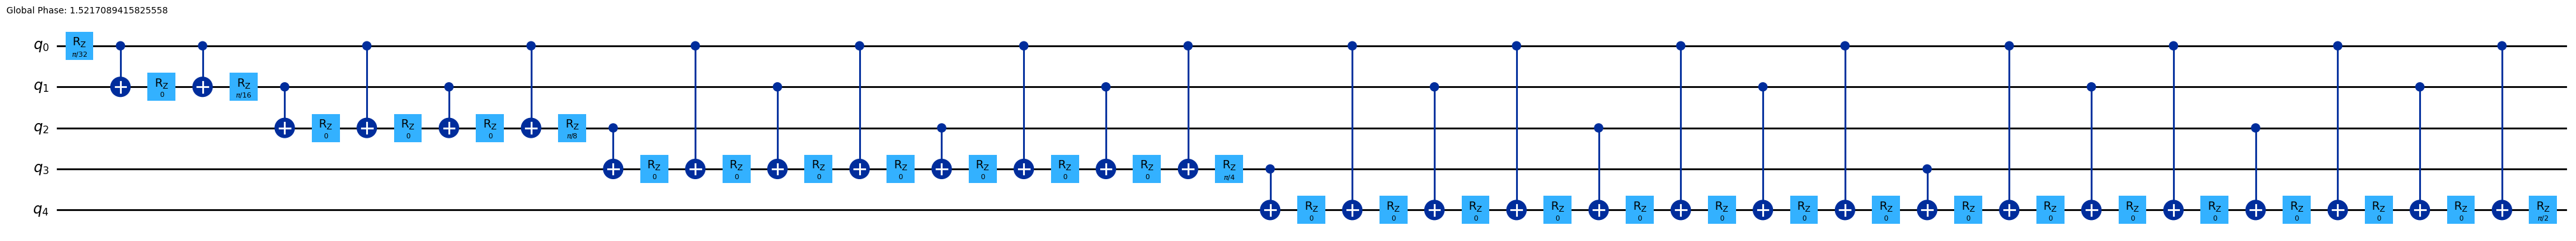

In [7]:
# phase angles
phases_5q = np.linspace(0, np.pi, 32, endpoint=False)

#build diag
diagU_5q =np.diag(np.exp(1j * phases_5q))


qc_5q = build_optimal_walsh_circuit(diagU_5q)

print(f"Generated 5-qubit circuit with depth: {qc_5q.depth()}")
qc_5q.draw('mpl', fold=-1)


Generated 6-qubit circuit with depth: 125


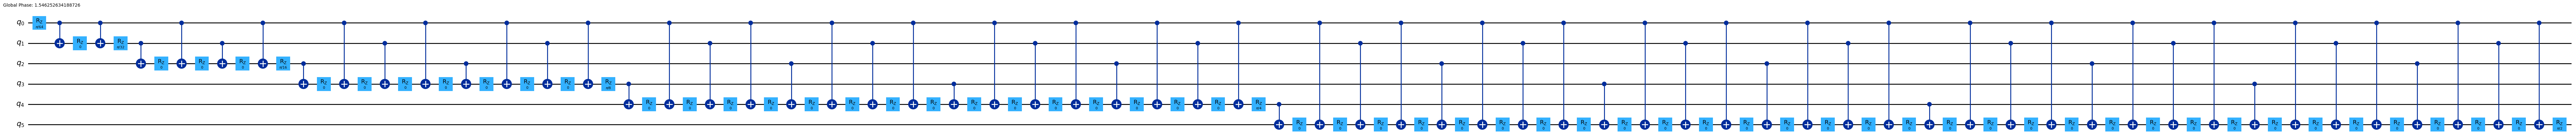

In [9]:

phases_6q = np.linspace(0, np.pi, 64, endpoint=False)

# 2. Build the Target Unitary (Diagonal)
# Note: Ensure you convert to complex exponentials for the gate
diagU_6q =np.diag(np.exp(1j * phases_6q))

# 3. Run Your Compiler
# (Assuming 'build_optimal_walsh_circuit' is your defined function)
# Ensure threshold is set to clean up tiny floating point noise
qc_6q = build_optimal_walsh_circuit(diagU_6q)

# 4. Compare vs Standard (Optional Visual Check)

# 5. Draw
print(f"Generated 6-qubit circuit with depth: {qc_6q.depth()}")
qc_6q.draw('mpl', fold=-1)


NEXT STEP: BENCHMARKING